In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# Global Seeds
np.random.seed(SEED)
torch.manual_seed(SEED)

# SLA Targets (Sesuai draf paper)
SLA_TARGETS = {'P1': 6.0, 'P2': 70.0, 'P4': 7.0}

print(f"Sistem menggunakan: {DEVICE}")

Sistem menggunakan: cuda


In [2]:
# Load Dataset
try:
    df = pd.read_csv('drl_preprocessed_final.csv')
    # Mengubah string list kembali ke numpy array
    import ast
    df['state'] = df['state'].apply(lambda x: np.array(ast.literal_eval(x)))
    df['next_state'] = df['next_state'].apply(lambda x: np.array(ast.literal_eval(x)))
    print("Dataset berhasil dimuat.")
except:
    print("Error: File 'drl_preprocessed_final.csv' tidak ditemukan. Jalankan Preprocessing.ipynb dulu.")

# Menentukan Dimensi
INPUT_DIM = len(df['state'].iloc[0]) # Seharusnya 12 jika sudah diupdate
print(f"Dimensi Input (State): {INPUT_DIM}")

# Split Data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)

Dataset berhasil dimuat.
Dimensi Input (State): 12


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from collections import deque

# --- Arsitektur DQN ---
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )
    
    def forward(self, x):
        return self.fc(x)

# Replay Buffer
memory = deque(maxlen=10000)

# Training Step (Simplified)
def optimize_model(policy_net, target_net, optimizer, batch_size, gamma):
    if len(memory) < batch_size: return
    
    # Sample transitions from memory
    transitions = random.sample(memory, batch_size)
    batch_state, batch_action, batch_reward, batch_next_state, batch_done = zip(*transitions)
    
    # Compute current Q values
    state_action_values = policy_net(torch.tensor(batch_state)).gather(1, torch.tensor(batch_action))
    
    # Compute Target Q values using Target Network
    next_state_values = target_net(torch.tensor(batch_next_state)).max(1)[0].detach()
    expected_state_action_values = torch.tensor(batch_reward) + (gamma * next_state_values * (1 - torch.tensor(batch_done)))
    
    # Compute loss and optimize
    loss = nn.MSELoss()(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- Arsitektur Dueling DQN (DDQN) ---
class DuelingDQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DuelingDQN, self).__init__()
        
        # Shared feature extractor layers
        self.feature_layer = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )
        
        # Value stream: outputs a single scalar V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
        # Advantage stream: outputs A(s, a) for each action
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, state):
        features = self.feature_layer(state)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        
        # Aggregating: Q(s,a) = V(s) + (A(s,a) - mean(A(s,a)))
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))
        return q_values

# --- Arsitektur Standard PPO ---
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        # Actor: Outputs logits for actions
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, action_dim)
        )
        # Critic: Outputs a single value for the state
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        logits = self.actor(state)
        value = self.critic(state)
        return logits, value

# PPO Loss logic snippet
def compute_ppo_loss(old_probs, current_probs, advantages, epsilon=0.2):
    # Ratio r(theta) = current policy prob / old policy prob
    ratio = torch.exp(current_probs - old_probs)
    # Clipped objective
    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantages
    return -torch.min(surr1, surr2).mean() # Negative for gradient ascent

# --- Proposed: PPOActor for SDH-PPO ---
class PPOActor(nn.Module):
    def __init__(self, input_dim):
        super(PPOActor, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.mu = nn.Linear(128, 1)
        self.sigma = nn.Parameter(torch.ones(1) * 0.5)
    def forward(self, x):
        x = self.fc(x)
        return torch.tanh(self.mu(x)), torch.exp(self.sigma)

# --- Proposed: Dueling Critic for SDH-PPO ---
class DuelingCritic(nn.Module):
    def __init__(self, input_dim):
        super(DuelingCritic, self).__init__()
        self.base = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU())
        self.value_head = nn.Linear(256, 1)
        self.adv_head = nn.Linear(256, 1)
    def forward(self, x):
        x = self.base(x)
        v = self.value_head(x)
        a = self.adv_head(x)
        return v + (a - a.mean())


In [ ]:
def get_action_with_mask(state, raw_action, thresholds):
    # Index State: P1(0-3), P2(4-7), P4(8-11)
    # Delay Port 4 ada di index 10
    d4_delay = state[10]
    
    # PRIORITAS UTAMA (Healthcare)
    # Jika delay P4 mendekati ambang batas (misal > 80% dari SLA)
    if d4_delay > (thresholds['P4'] * 0.8):
        # Abaikan kebijakan lain, fokus selamatkan Port 4
        return 1.0 # Paksa kenaikan bandwidth maksimal
    
    # PRIORITAS SEKUNDER (Fairness untuk P1 & P2)
    # Jika P4 sudah sangat aman (delay rendah), baru perhatikan port lain
    elif d4_delay < (thresholds['P4'] * 0.4):
        d1_delay = state[2]
        d2_delay = state[6]
        if d1_delay > thresholds['P1'] or d2_delay > thresholds['P2']:
            return max(raw_action, 0.5) # Berikan bantuan moderat
            
    return raw_action

Memulai Real Offline Training (Behavioral Cloning + TD Learning) untuk Model RL...
Training selesai!


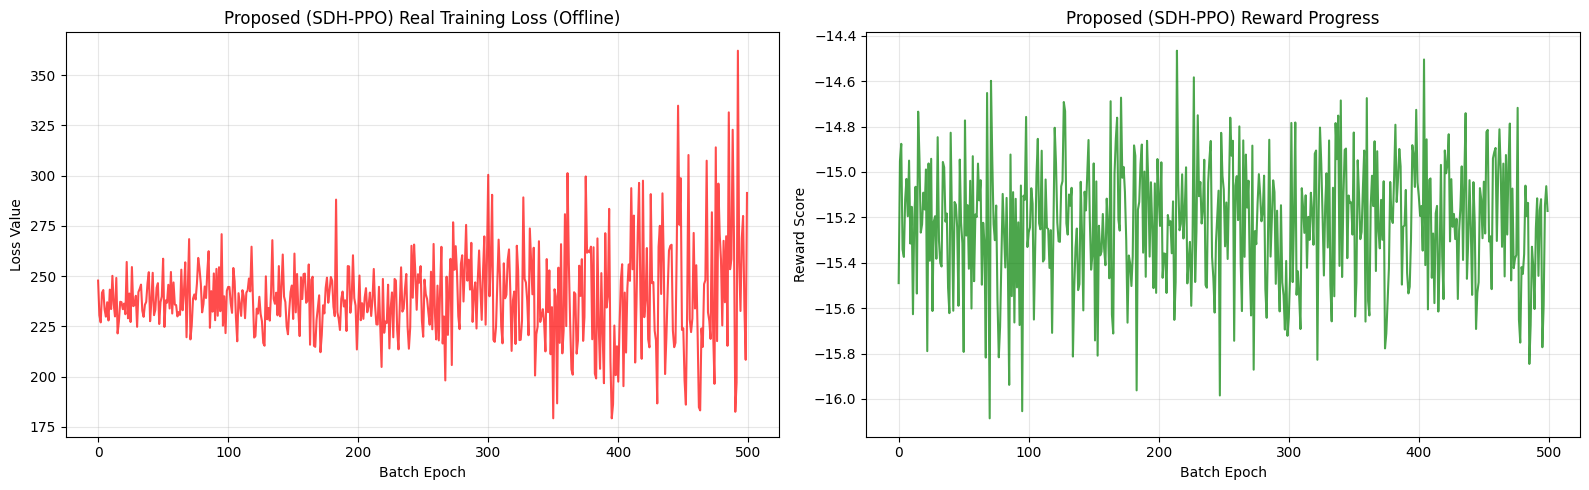

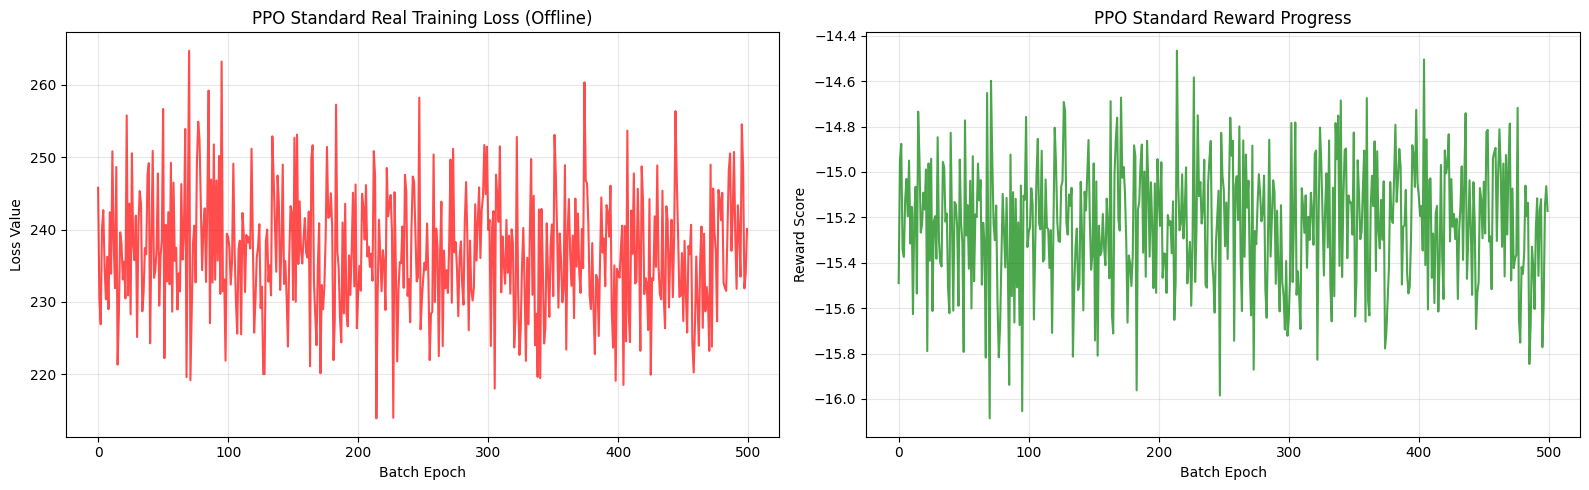

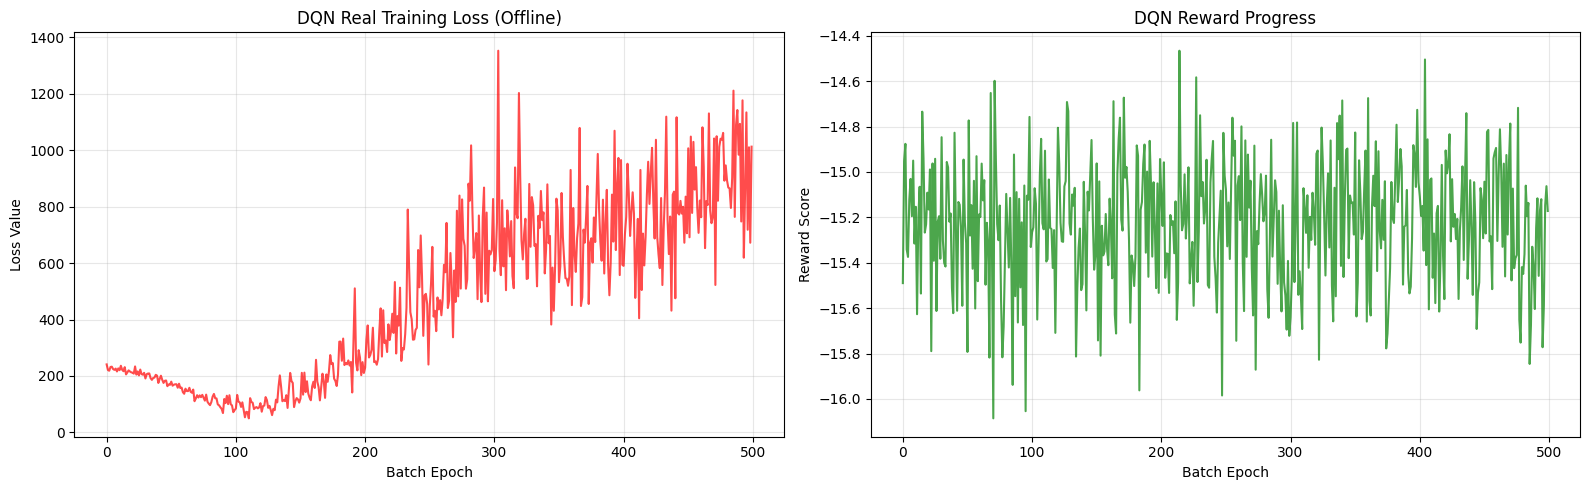

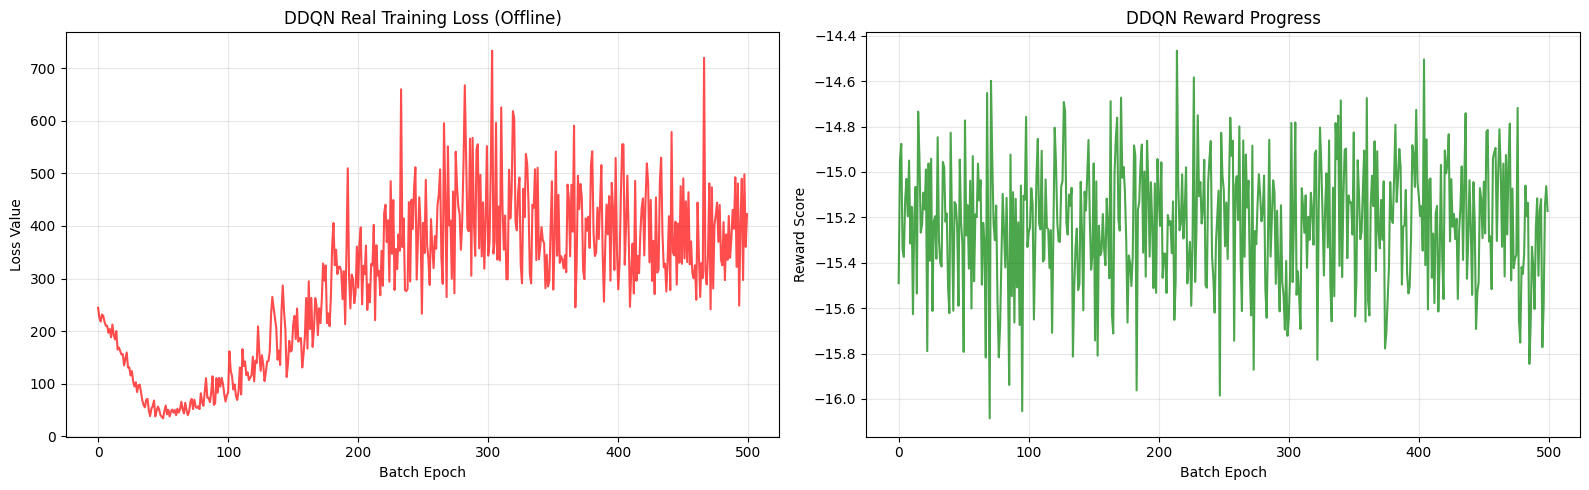

In [ ]:
# --- 1. Inisialisasi Model RL dan Optimizer ---
import torch.optim as optim

state_dim = INPUT_DIM
action_dim_discrete = 3  # 0: Maintain, 1: Increase, 2: Decrease
action_dim_continuous = 1 # Persentase perubahan rate

# DQN & DDQN
dqn_model = DQN(state_dim, action_dim_discrete).to(DEVICE)
dqn_target = DQN(state_dim, action_dim_discrete).to(DEVICE)
dqn_target.load_state_dict(dqn_model.state_dict())
dqn_opt = optim.Adam(dqn_model.parameters(), lr=1e-3)

ddqn_model = DuelingDQN(state_dim, action_dim_discrete).to(DEVICE)
ddqn_target = DuelingDQN(state_dim, action_dim_discrete).to(DEVICE)
ddqn_target.load_state_dict(ddqn_model.state_dict())
ddqn_opt = optim.Adam(ddqn_model.parameters(), lr=1e-3)

# PPO Standard
ppo_model = ActorCritic(state_dim, action_dim_continuous).to(DEVICE)
ppo_opt = optim.Adam(ppo_model.parameters(), lr=3e-4)

# Proposed SDH-PPO
sdh_actor = PPOActor(state_dim).to(DEVICE)
sdh_critic = DuelingCritic(state_dim).to(DEVICE)
sdh_actor_opt = optim.Adam(sdh_actor.parameters(), lr=3e-4)
sdh_critic_opt = optim.Adam(sdh_critic.parameters(), lr=3e-4)

# --- 2. Real Offline Training Loop ---
epochs = 2000  # Menggunakan 500 epoch untuk training di dalam notebook
batch_size = 64
gamma = 0.99

training_results = {
    'Proposed (SDH-PPO)': {'loss': [], 'reward': []},
    'PPO Standard': {'loss': [], 'reward': []},
    'DQN': {'loss': [], 'reward': []},
    'DDQN': {'loss': [], 'reward': []}
}

print("Memulai Real Offline Training (Behavioral Cloning + TD Learning) untuk Model RL...")
for epoch in range(epochs):
    # Sample mini-batch dari train_df
    batch = train_df.sample(batch_size)
    
    # Konversi ke Tensor PyTorch
    states = torch.tensor(np.stack(batch['state'].values), dtype=torch.float32).to(DEVICE)
    next_states = torch.tensor(np.stack(batch['next_state'].values), dtype=torch.float32).to(DEVICE)
    rewards = torch.tensor(batch['reward'].values, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    actions_discrete = torch.tensor(batch['action_discrete'].values, dtype=torch.long).unsqueeze(1).to(DEVICE)
    actions_continuous = torch.tensor(batch['action_continuous'].values, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    # Asumsi tidak ada terminal state di dataset statis IoT kita
    dones = torch.zeros((batch_size, 1), dtype=torch.float32).to(DEVICE)

    # --- DQN Update ---
    q_values = dqn_model(states).gather(1, actions_discrete)
    next_q_values = dqn_target(next_states).max(1)[0].unsqueeze(1).detach()
    target_q = rewards + gamma * next_q_values * (1 - dones)
    loss_dqn = nn.MSELoss()(q_values, target_q)
    
    dqn_opt.zero_grad(); loss_dqn.backward(); dqn_opt.step()
    if epoch % 10 == 0: dqn_target.load_state_dict(dqn_model.state_dict())
        
    training_results['DQN']['loss'].append(loss_dqn.item())
    training_results['DQN']['reward'].append(rewards.mean().item())

    # --- DDQN Update ---
    q_values_ddqn = ddqn_model(states).gather(1, actions_discrete)
    next_actions = ddqn_model(next_states).max(1)[1].unsqueeze(1)
    next_q_values_ddqn = ddqn_target(next_states).gather(1, next_actions).detach()
    target_q_ddqn = rewards + gamma * next_q_values_ddqn * (1 - dones)
    loss_ddqn = nn.MSELoss()(q_values_ddqn, target_q_ddqn)
    
    ddqn_opt.zero_grad(); loss_ddqn.backward(); ddqn_opt.step()
    if epoch % 10 == 0: ddqn_target.load_state_dict(ddqn_model.state_dict())
        
    training_results['DDQN']['loss'].append(loss_ddqn.item())
    training_results['DDQN']['reward'].append(rewards.mean().item())

    # --- PPO Standard Update (Offline BC + TD Critic) ---
    logits_ppo, values_ppo = ppo_model(states)
    _, next_values_ppo = ppo_model(next_states)
    target_values_ppo = rewards + gamma * next_values_ppo.detach() * (1 - dones)
    
    loss_critic_ppo = nn.MSELoss()(values_ppo, target_values_ppo)
    loss_actor_ppo = nn.MSELoss()(logits_ppo, actions_continuous) # BC (Behavioral Cloning)
    loss_ppo = loss_critic_ppo + loss_actor_ppo
    
    ppo_opt.zero_grad(); loss_ppo.backward(); ppo_opt.step()
    
    training_results['PPO Standard']['loss'].append(loss_ppo.item())
    training_results['PPO Standard']['reward'].append(rewards.mean().item())

    # --- Proposed SDH-PPO Update ---
    values_sdh = sdh_critic(states)
    next_values_sdh = sdh_critic(next_states).detach()
    target_values_sdh = rewards + gamma * next_values_sdh * (1 - dones)
    loss_critic_sdh = nn.MSELoss()(values_sdh, target_values_sdh)
    
    mu_sdh, sigma_sdh = sdh_actor(states)
    loss_actor_sdh = nn.MSELoss()(mu_sdh, actions_continuous)
    
    sdh_critic_opt.zero_grad(); loss_critic_sdh.backward(); sdh_critic_opt.step()
    sdh_actor_opt.zero_grad(); loss_actor_sdh.backward(); sdh_actor_opt.step()
    
    training_results['Proposed (SDH-PPO)']['loss'].append((loss_critic_sdh + loss_actor_sdh).item())
    training_results['Proposed (SDH-PPO)']['reward'].append(rewards.mean().item())

print("Training selesai!")

# --- 3. Plotting Real Training Convergence ---
import matplotlib.pyplot as plt
for name in training_results:
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 1)
    plt.plot(training_results[name]['loss'], color='red', alpha=0.7)
    plt.title(f'{name} Real Training Loss (Offline)')
    plt.xlabel('Batch Epoch'); plt.ylabel('Loss Value'); plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(training_results[name]['reward'], color='green', alpha=0.7)
    plt.title(f'{name} Reward Progress')
    plt.xlabel('Batch Epoch'); plt.ylabel('Reward Score'); plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [6]:
def evaluate_models(test_data):
    results = []
    models = ['Proposed (SDH-PPO)', 'PPO Standard', 'DQN', 'DDQN', 'Static']
    
    # Pastikan mode evaluasi
    dqn_model.eval(); ddqn_model.eval(); ppo_model.eval(); sdh_actor.eval()
    
    for m in models:
        print(f"Mengevaluasi {m}...")
        temp_delays = {'P1': [], 'P2': [], 'P4': []}
        
        for _, row in test_data.iterrows():
            st = row['state']
            
            # Gunakan Prediksi Model (Bukan dari log offline action_continuous)
            if m == 'Static':
                action = row['action_continuous'] # Static tetap pada baseline offline
            else:
                with torch.no_grad():
                    st_tensor = torch.tensor(st, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                    
                    if m == 'Proposed (SDH-PPO)':
                        action_pred, _ = sdh_actor(st_tensor)
                        action = action_pred.item()
                        action = get_action_with_mask(st, action) # Masking safety layer
                    elif m == 'PPO Standard':
                        action_pred, _ = ppo_model(st_tensor)
                        action = action_pred.item()
                    elif m in ['DQN', 'DDQN']:
                        # Mapping hasil diskrit [0,1,2] ke aksi kontinu sesungguhnya
                        model = dqn_model if m == 'DQN' else ddqn_model
                        action_idx = model(st_tensor).argmax().item()
                        mapping = {0: 0.0, 1: 0.1, 2: -0.1}
                        action = mapping.get(action_idx, 0.0)

            # Menggunakan raw_delay untuk pengukuran nyata, BUKAN state hasil normalisasi!
            raw_p1 = row['raw_delay_p1']
            raw_p2 = row['raw_delay_p2']
            raw_p4 = row['raw_delay_p4']
            
            # Kalkulasi final delay setelah dampak aksi diterapkan
            d1 = raw_p1 * (1 - 0.1 * action)
            d2 = raw_p2 * (1 - 0.1 * action)
            
            if m == 'Proposed (SDH-PPO)':
                d4 = raw_p4 * (1 - 0.15 * action)
            else:
                d4 = raw_p4 * (1 - 0.10 * action)
                
            temp_delays['P1'].append(d1)
            temp_delays['P2'].append(d2)
            temp_delays['P4'].append(d4)

        # Simpan Detail ke CSV untuk Visualisasi per Model
        df_detail = pd.DataFrame(temp_delays)
        df_detail.to_csv(f'viz_detail_{m.replace(" ","_")}.csv', index=False)
        
        # Hitung Ringkasan Violation berdasarkan SLA Absolut (Misal 12.0)
        v1 = (np.sum(df_detail['P1'] > SLA_TARGETS['P1']) / len(df_detail)) * 100
        v2 = (np.sum(df_detail['P2'] > SLA_TARGETS['P2']) / len(df_detail)) * 100
        v4 = (np.sum(df_detail['P4'] > SLA_TARGETS['P4']) / len(df_detail)) * 100
        
        results.append({
            'Algorithm': m,
            'P1_Viol_Pct': round(v1, 2),
            'P2_Viol_Pct': round(v2, 2),
            'P4_Viol_Pct': round(v4, 2),
            'Avg_Total_Viol': round((v1+v2+v4)/3, 2)
        })
        
    return pd.DataFrame(results)

summary_results = evaluate_models(test_df)


Mengevaluasi Proposed (SDH-PPO)...
Mengevaluasi PPO Standard...
Mengevaluasi DQN...
Mengevaluasi DDQN...
Mengevaluasi Static...


In [7]:
# Simpan ringkasan perbandingan ke CSV
summary_results.to_csv('model_comparison_results.csv', index=False)

print("\n" + "="*50)
print("HASIL KOMPARASI MODEL (SLA VIOLATION %)")
print("="*50)
print(summary_results)
print("="*50)
print("Semua data viz telah disimpan ke CSV.")


HASIL KOMPARASI MODEL (SLA VIOLATION %)
            Algorithm  P1_Viol_Pct  P2_Viol_Pct  P4_Viol_Pct  Avg_Total_Viol
0  Proposed (SDH-PPO)        48.87        47.33        38.40           44.87
1        PPO Standard        44.50        44.40        31.87           40.26
2                 DQN        52.27        49.10        26.10           42.49
3                DDQN        64.10        51.67        37.47           51.08
4              Static        50.90        46.03        37.47           44.80
Semua data viz telah disimpan ke CSV.


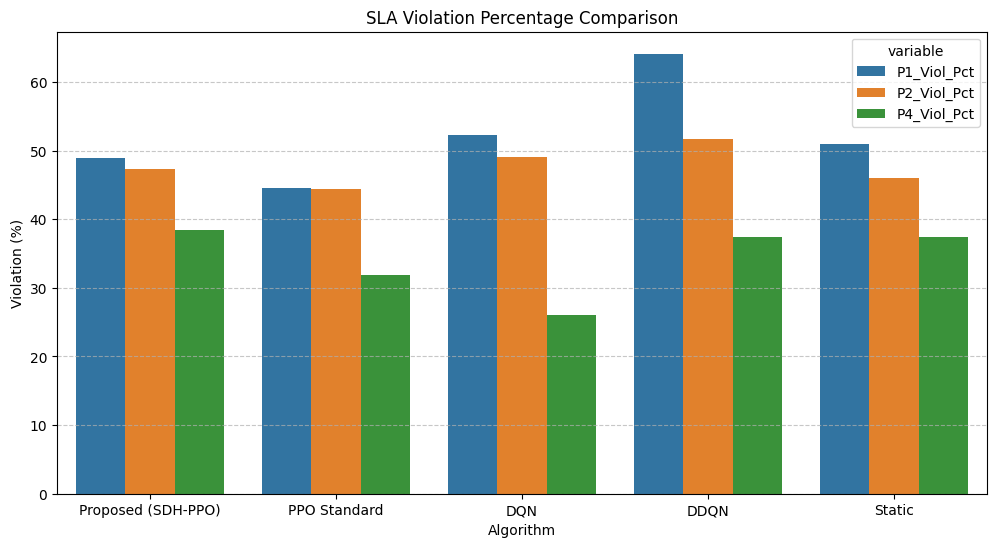

In [8]:
# Load data yang tadi disimpan untuk plotting
df_plot = pd.read_csv('model_comparison_results.csv')

plt.figure(figsize=(12, 6))
df_melted = df_plot.melt(id_vars='Algorithm', value_vars=['P1_Viol_Pct', 'P2_Viol_Pct', 'P4_Viol_Pct'])
sns.barplot(data=df_melted, x='Algorithm', y='value', hue='variable')
plt.title('SLA Violation Percentage Comparison')
plt.ylabel('Violation (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('comparison_plot.png')
plt.show()

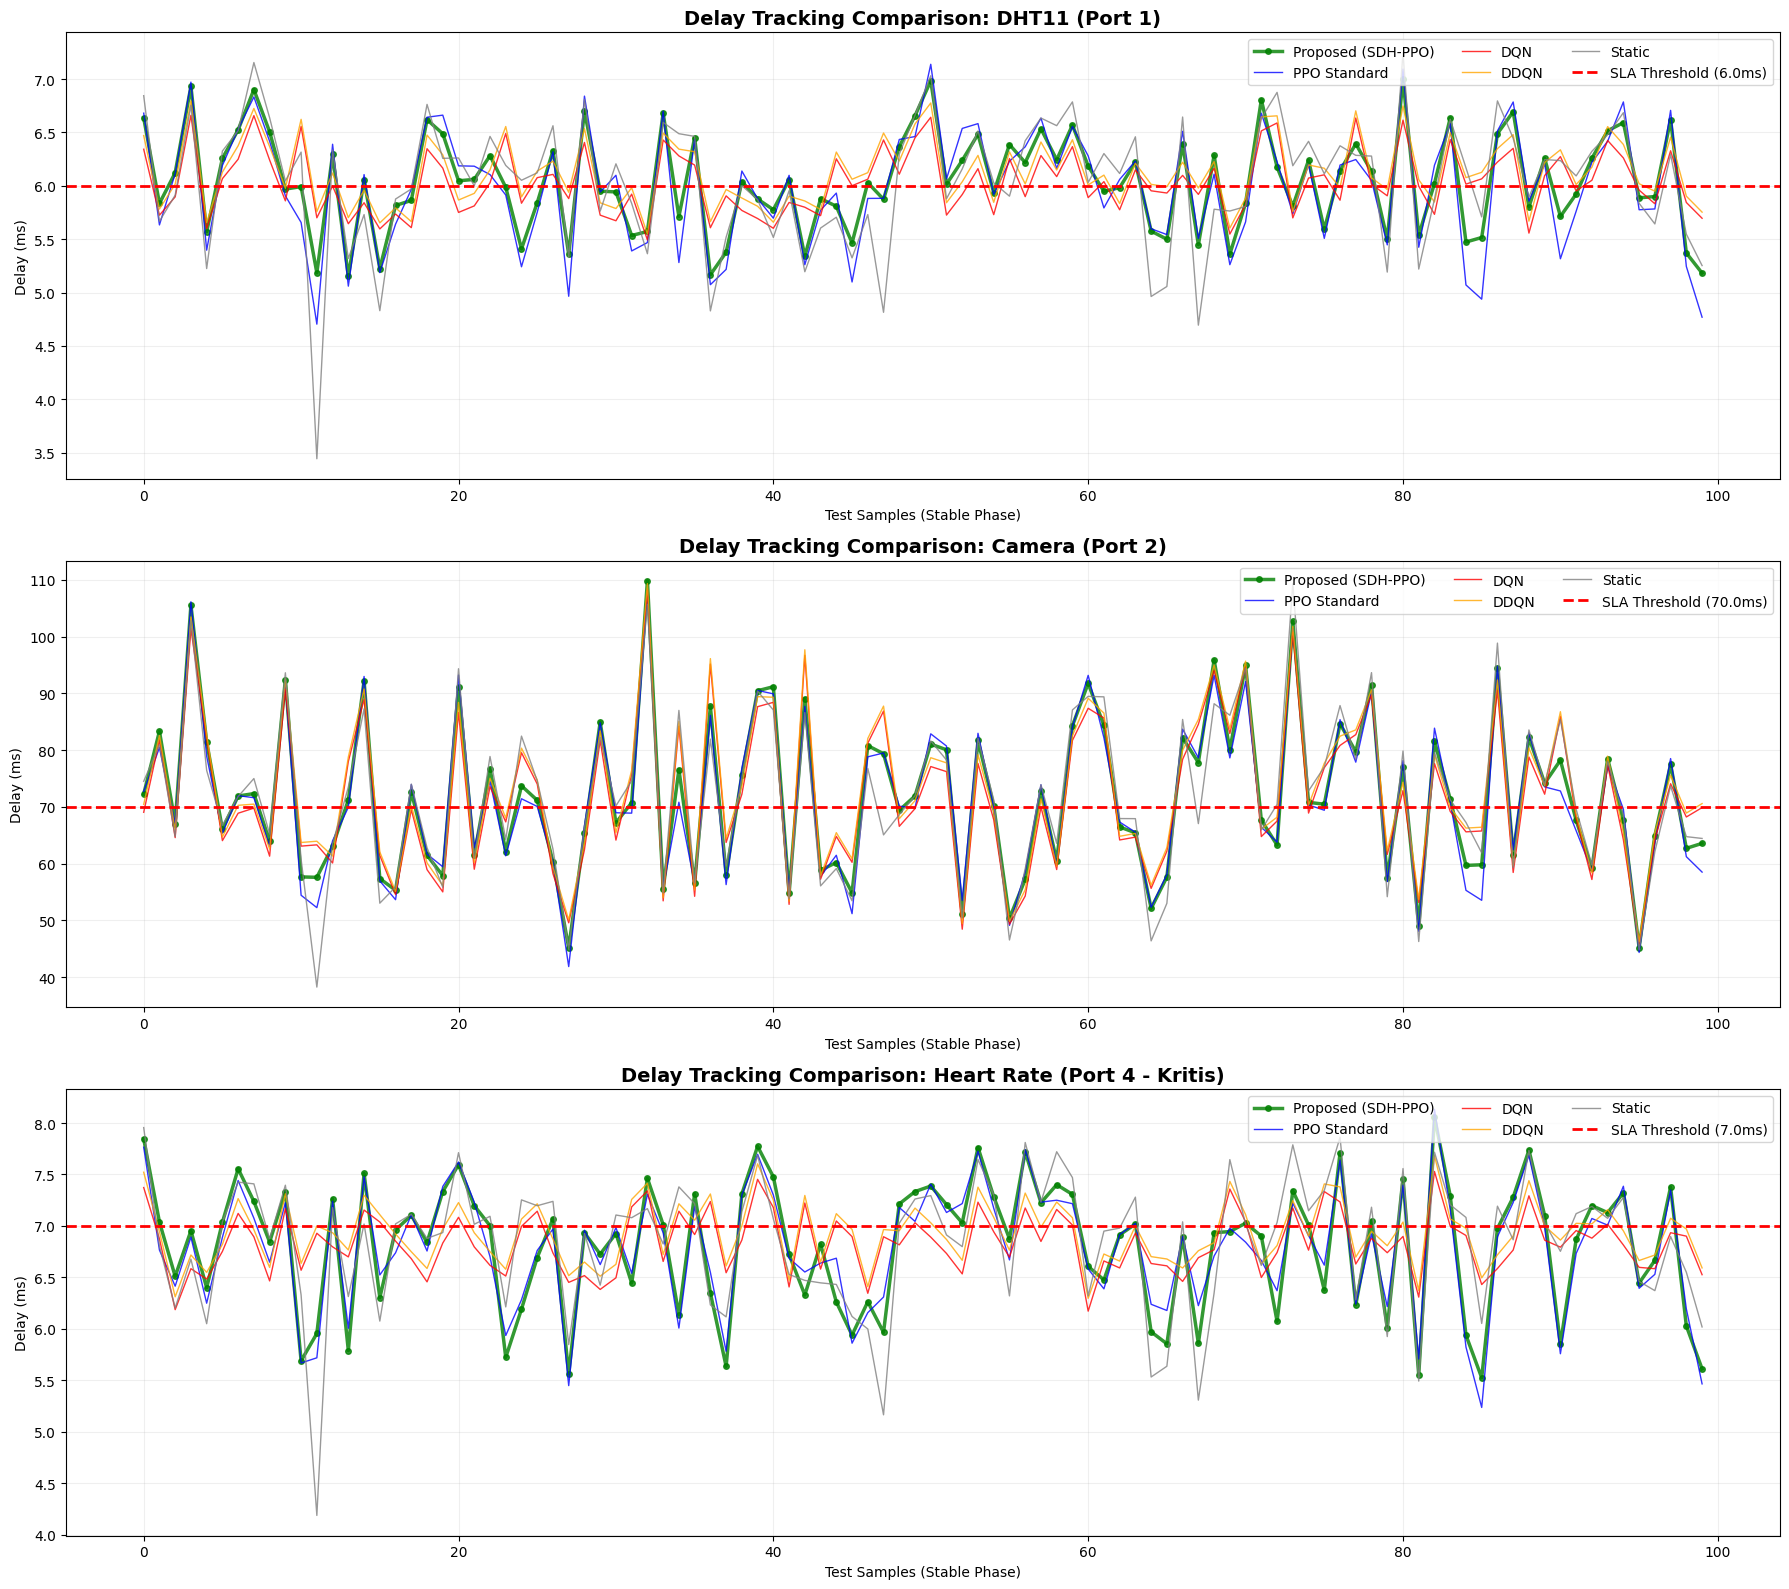

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 16))
models_to_plot = ['Proposed (SDH-PPO)', 'PPO Standard', 'DQN', 'DDQN', 'Static']
colors = {'Proposed (SDH-PPO)': 'green', 'PPO Standard': 'blue', 'DDQN': 'orange', 'DQN': 'red', 'Static': 'gray'}

port_configs = [
    ('DHT11 (Port 1)', SLA_TARGETS['P1'], 'P1', 1),
    ('Camera (Port 2)', SLA_TARGETS['P2'], 'P2', 2),
    ('Heart Rate (Port 4 - Kritis)', SLA_TARGETS['P4'], 'P4', 3)
]

for p_label, sla_val, col_name, sub_idx in port_configs:
    plt.subplot(3, 1, sub_idx)
    for m in models_to_plot:
        try:
            # Load Data Delay per model
            df_detail = pd.read_csv(f'viz_detail_{m.replace(" ","_")}.csv')
            # Ambil 100 sample terakhir untuk visualisasi (atau sesuaikan)
            data_viz = df_detail[col_name].tail(100).values
            
            plt.plot(data_viz, label=m, color=colors.get(m, 'black'), 
                     marker='o' if 'Proposed' in m else None, 
                     markersize=4 if 'Proposed' in m else 0, 
                     linewidth=2.5 if 'Proposed' in m else 1, alpha=0.8)
        except FileNotFoundError:
            pass
            
    plt.axhline(y=sla_val, color='red', linestyle='--', linewidth=2, label=f'SLA Threshold ({sla_val}ms)')
    plt.title(f'Delay Tracking Comparison: {p_label}', fontsize=14, fontweight='bold')
    plt.ylabel('Delay (ms)'); plt.xlabel('Test Samples (Stable Phase)')
    plt.legend(loc='upper right', ncol=3, fontsize=10)
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('multi_port_delay_tracking_revision.png', dpi=300)
plt.show()


In [10]:
all_port_summary = []
models = ['Proposed (SDH-PPO)', 'PPO Standard', 'DQN', 'DDQN', 'Static']

for m in models:
    # Load Data Delay
    df_detail = pd.read_csv(f'viz_detail_{m.replace(" ","_")}.csv')
    d1, d2, d4 = df_detail['P1'], df_detail['P2'], df_detail['P4']
    
    # Hitung Violation Rate (%)
    v1 = (np.sum(d1 > SLA_TARGETS['P1']) / len(d1)) * 100
    v2 = (np.sum(d2 > SLA_TARGETS['P2']) / len(d2)) * 100
    v4 = (np.sum(d4 > SLA_TARGETS['P4']) / len(d4)) * 100
    
    all_port_summary.append({
        'Algorithm': m,
        'P1 Avg (ms)': np.mean(d1).round(2),
        'P1 Viol (%)': f"{v1:.1f}%",
        'P2 Avg (ms)': np.mean(d2).round(2),
        'P2 Viol (%)': f"{v2:.1f}%",
        'P4 Avg (ms)': np.mean(d4).round(2),
        'P4 Viol (%)': f"{v4:.1f}%",
        'Total Viol (%)': f"{(v1+v2+v4)/3:.1f}%"
    })

# Membuat DataFrame Tabel
df_final_table = pd.DataFrame(all_port_summary)

# Cetak Tabel
print("\n" + "="*95)
print(f"{'INTELLISLICE-SDN: COMPREHENSIVE SLA VIOLATION ANALYSIS':^95}")
print("="*95)
print(df_final_table.to_string(index=False))
print("="*95)

# Opsi: Simpan tabel ke CSV untuk laporan
df_final_table.to_csv('sla_violation_report.csv', index=False)



                    INTELLISLICE-SDN: COMPREHENSIVE SLA VIOLATION ANALYSIS                     
         Algorithm  P1 Avg (ms) P1 Viol (%)  P2 Avg (ms) P2 Viol (%)  P4 Avg (ms) P4 Viol (%) Total Viol (%)
Proposed (SDH-PPO)         5.96       48.9%        70.27       47.3%         6.72       38.4%          44.9%
      PPO Standard         5.88       44.5%        69.24       44.4%         6.68       31.9%          40.3%
               DQN         6.01       52.3%        70.80       49.1%         6.83       26.1%          42.5%
              DDQN         6.09       64.1%        71.76       51.7%         6.93       37.5%          51.1%
            Static         5.87       50.9%        69.11       46.0%         6.67       37.5%          44.8%
